In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt


In [3]:
import seaborn as sns

In [4]:
from google.colab import files

In [5]:
uploaded = files.upload()

Saving FAOSTAT_data_en_9-29-2026.csv to FAOSTAT_data_en_9-29-2026.csv


In [6]:
df = pd.read_csv("/content/FAOSTAT_data_en_9-29-2026.csv")

In [7]:
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,434,Libya,5610,Import quantity,1314,Dates,2020,2020,t,1739.02,X,Value from external organization,Estimated data using trading partners database
1,TCL,Crops and livestock products,434,Libya,5910,Export quantity,1314,Dates,2020,2020,t,5439.98,X,Value from external organization,Estimated data using trading partners database
2,TCL,Crops and livestock products,434,Libya,5610,Import quantity,1314,Dates,2021,2021,t,6277.22,X,Value from external organization,Estimated data using trading partners database
3,TCL,Crops and livestock products,434,Libya,5910,Export quantity,1314,Dates,2021,2021,t,3239.20,X,Value from external organization,Estimated data using trading partners database
4,TCL,Crops and livestock products,434,Libya,5610,Import quantity,1314,Dates,2022,2022,t,12310.71,X,Value from external organization,Estimated data using trading partners database


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       36 non-null     object 
 1   Domain            36 non-null     object 
 2   Area Code (M49)   36 non-null     int64  
 3   Area              36 non-null     object 
 4   Element Code      36 non-null     int64  
 5   Element           36 non-null     object 
 6   Item Code (CPC)   36 non-null     int64  
 7   Item              36 non-null     object 
 8   Year Code         36 non-null     int64  
 9   Year              36 non-null     int64  
 10  Unit              36 non-null     object 
 11  Value             36 non-null     float64
 12  Flag              36 non-null     object 
 13  Flag Description  36 non-null     object 
 14  Note              33 non-null     object 
dtypes: float64(1), int64(5), object(9)
memory usage: 4.3+ KB


In [12]:
df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [13]:
df.shape

(36, 15)

In [14]:
df.isnull().sum()

,0
Domain Code,0
Domain,0
Area Code (M49),0
Area,0
Element Code,0
Element,0
Item Code (CPC),0
Item,0
Year Code,0
Year,0


In [16]:
df['Item'].unique()

array(['Dates', 'Potatoes', 'Tomatoes', 'Wheat'], dtype=object)

In [17]:
df['Element'].unique()

array(['Import quantity', 'Export quantity'], dtype=object)

In [19]:
df['Year'].min, df['Year'].max()

(<bound method Series.min of 0     2020
 1     2020
 2     2021
 3     2021
 4     2022
 5     2022
 6     2023
 7     2023
 8     2024
 9     2024
 10    2020
 11    2020
 12    2021
 13    2021
 14    2022
 15    2022
 16    2023
 17    2023
 18    2024
 19    2024
 20    2020
 21    2021
 22    2021
 23    2022
 24    2022
 25    2023
 26    2023
 27    2024
 28    2020
 29    2020
 30    2021
 31    2022
 32    2023
 33    2023
 34    2024
 35    2024
 Name: Year, dtype: int64>,
 2024)

In [20]:
df = df[['Area', 'Item', 'Element', 'Year', 'Unit', 'Value']].copy()
df = df.sort_values(['Item', 'Element', 'Year']).reset_index(drop=True)
df.head(10)

,Area,Item,Element,Year,Unit,Value
0,Libya,Dates,Export quantity,2020,t,5439.98
1,Libya,Dates,Export quantity,2021,t,3239.20
2,Libya,Dates,Export quantity,2022,t,3200.51
3,Libya,Dates,Export quantity,2023,t,6274.08
4,Libya,Dates,Export quantity,2024,t,2569.89
5,Libya,Dates,Import quantity,2020,t,1739.02
6,Libya,Dates,Import quantity,2021,t,6277.22
7,Libya,Dates,Import quantity,2022,t,12310.71
8,Libya,Dates,Import quantity,2023,t,4109.00
9,Libya,Dates,Import quantity,2024,t,251.27


In [21]:
pivot = df.pivot_table(
    index=['Item', 'Year'],
    columns='Element',
    values='Value'

).reset_index()
pivot.head(20)

Element,Item,Year,Export quantity,Import quantity
0,Dates,2020,5439.98,1739.02
1,Dates,2021,3239.20,6277.22
2,Dates,2022,3200.51,12310.71
3,Dates,2023,6274.08,4109.00
4,Dates,2024,2569.89,251.27
5,Potatoes,2020,3300.00,15732.88
6,Potatoes,2021,504.00,12324.20
7,Potatoes,2022,86.00,16477.48
8,Potatoes,2023,18989.60,17492.59
9,Potatoes,2024,55.00,15210.60


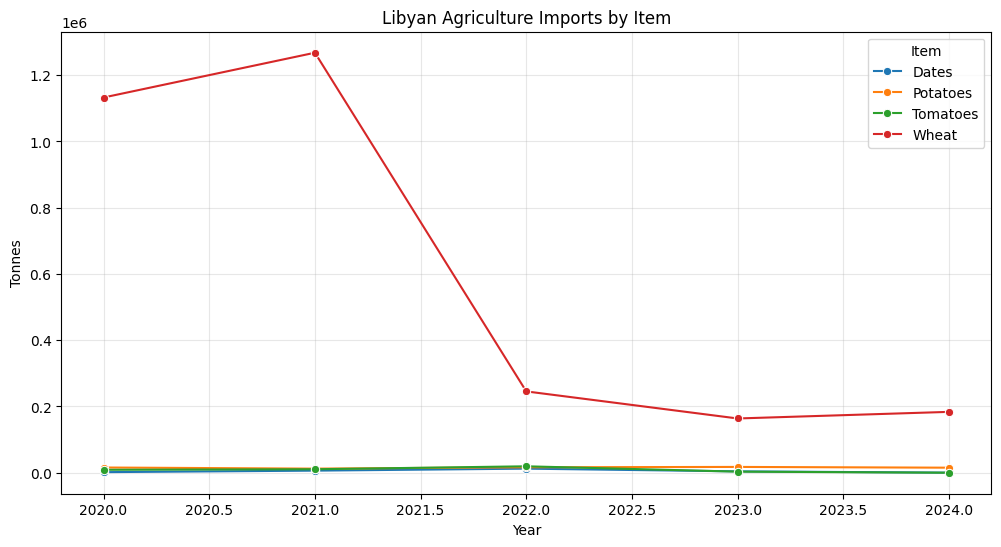

In [22]:
plt.figure(figsize=(12,6))
sns.lineplot(data=pivot, x='Year', y='Import quantity', hue='Item', marker='o')
plt.title('Libyan Agriculture Imports by Item')
plt.ylabel('Tonnes')
plt.grid(alpha=0.3)
plt.show()

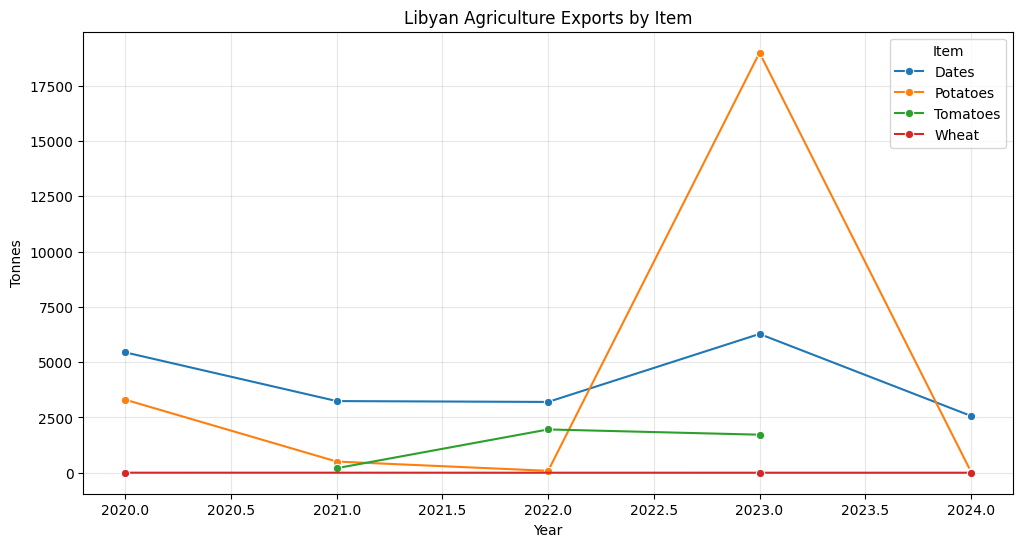

In [23]:
plt.figure(figsize=(12,6))
sns.lineplot(data=pivot, x='Year', y='Export quantity', hue='Item', marker='o')
plt.title('Libyan Agriculture Exports by Item')
plt.ylabel('Tonnes')
plt.grid(alpha=0.3)
plt.show()

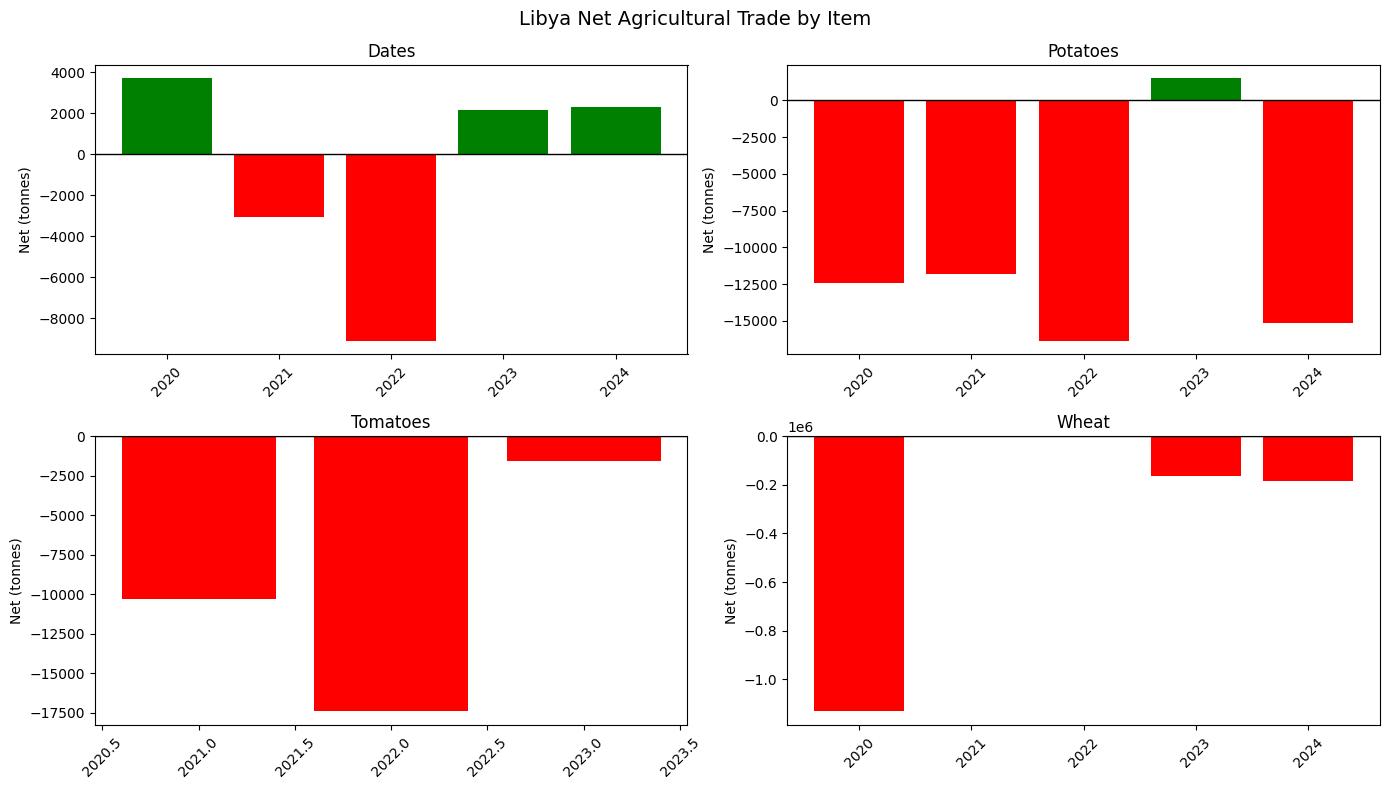

In [25]:
items = pivot['Item'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, item in zip(axes.flat, items):
    data = pivot[pivot['Item'] == item]
    ax.bar(data['Year'], data['Net'],
           color=['red' if x < 0 else 'green' for x in data['Net']])
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(item)
    ax.set_ylabel('Net (tonnes)')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Libya Net Agricultural Trade by Item', fontsize=14)
plt.tight_layout()
plt.show()

# Findings:

1. Wheat is Libya's biggest agricultural problem. Every year from 2020 to 2024 Libya imported over one million tonnes more wheat than it exported, no other crop comes close to this scale.

2. Dates are Libya's only real export crop. Dates were the only item that exported more than it imported in most years, but the numbers went up and down a lot with some years flipping to net imports.

3. Potatoes and tomatoes are imports not exports. Even though Libya is often assumed to grow these well the data shows the opposite, both crops were mostly net imports across the years analyzed.

4. Wheat imports are so large that they make all other crops look tiny on the same chart. This shows Libya's agricultural trade is highly unbalanced and depends heavily on wheat from outside the country.